In [1]:
!pip install -q google-generativeai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini image initialized successfully.
Enter your housing requirements here, include location, price, amenities, safety concerns, miscelanious 
(ie: I need to rent a room near San Jose State University for under $1500 per month, It would be nice to have a room to myself and a parking spot and I wouldnt want it to be too old.)I need to rent a room near San Jose State University for under $1500 per month, It would be nice to have a room to myself and a parking spot and I wouldnt want it to be too old
--- Resident message ---
I need to rent a room near San Jose State University for under $1500 per month, It would be nice to have a room to myself and a parking spot and I wouldnt want it to be too old

--- Structured extraction

Run 1:
{
  "location": "San Jose State University",
  "Price": "Less than $1500",
  "Shared": "No",
  "Amenities": "Parking spot",
  "Safety": "Building age not too old",
  "House mates?": "Not Specified",
  "Miscelanious": "Not Specified"
}


Saving Screenshot 2026-05-03 181614.png to Screenshot 2026-05-03 181614.png
Uploaded: Screenshot 2026-05-03 181614.png
Image size: 695x468 pixels


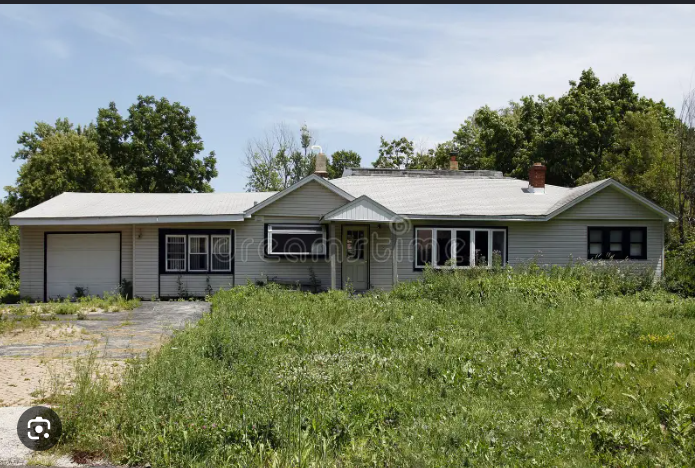

analyze_image() function defined. Ready to use in Parts 3 and 4.
--- Safety ---
Yes, there are several visible safety problems in this image, primarily related to neglect and poor maintenance:

1.  **Overgrown Vegetation (Severe Tripping Hazard & Pest Harborage):** The entire front yard is covered in very tall, dense weeds and grass.
    *   **Tripping Hazard:** This extensive growth completely obscures the ground, making it impossible to see uneven surfaces, holes, debris, or roots, posing a significant tripping hazard for anyone approaching the house.
    *   **Pest Harborage:** Such dense vegetation provides an ideal habitat for rodents (mice, rats), insects (ticks, mosquitoes, spiders), and potentially snakes, increasing the risk of bites, stings, and infestations.
    *   **Fire Hazard:** In dry conditions, this overgrown vegetation becomes highly flammable, increasing the risk of a brush fire spreading to the house or adjacent properties.
    *   **Security Risk:** It provides co

In [2]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os
import json

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini image initialized successfully.")

resident_message = (
    input("Enter your housing requirements here, include location, price, amenities, safety concerns, miscelanious \n(ie: I need to rent a room near San Jose State University for under $1500 per month, It would be nice to have a room to myself and a parking spot and I wouldnt want it to be too old.)")
)
#resident message will be later taken as an input, for now this is just for testing
def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the housing requirements such as: Location, price, yes or no for housemates, amenities, and miscelanious from this housing request."
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    return response.text

print("--- Resident message ---")
print(resident_message)

schema_prompt = """
Extract information from this housing request, IF anything is missing just say "Not Specified"
Return ONLY valid JSON with exactly these fields:
{
  "location": string (the street address or location described),
  "Price": The range of prices,
  "Shared": Wether or not roomates/housemates are ok,
  "Amenities": string (which amenities do they want, such as parking, fridge, washing unit, pool, grill, lawn, etc),
  "Safety": string (What level of Safety is permissible) including age of building
  "Miscelanious": string (any other details given that dont fall into these categories)
}
Safety guide: LOW = small litter or cosmetic issue, MEDIUM = large items or ongoing problem, HIGH = hazardous materials or immediate safety risk.
No explanation. No markdown. JSON only.
"""
def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

#print("--- Resident message ---")
#print(resident_message)
print("\n--- Structured extraction")

for i in range(1, 2):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

    # Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

def analyze_image(image_path, question, requirements=None):
    """
    Send an image + a question + optional structured requirements to Gemini.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)

    if requirements:
        question = f"""
Use these resident housing requirements:

{json.dumps(requirements, indent=2)}

Now answer this question about the image:
{question}
"""

    response = m.generate_content([question, img])
    time.sleep(12)
    return response.text, response.usage_metadata
print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

home_questions = [
    ("Safety",  "Describe if there is a safety problem visible in this image. Be specific about what you see."),
    ("Style",   "What style home is this, Is it an apartment, condo, or a single family home?"),
    ("Rating",  "Rate the home as LOW, MEDIUM, or HIGH tier. Explain your rating in 2–3 sentences."),
    ("Cleansiness",   "Is the home clean and tidy, is it modern or old?"),
    ("Size", "Based on the image and the resident requirements, does this home appear large enough for the requested living situation, or too large? Explain briefly."),
    ("Fit", "Compare this home against the structured resident requirements inluding the apparent amenities, safety, and miscelanious. Say whether it is a good fit, partial fit, or poor fit, and explain why.")
]

home_results = {"answers": {}, "total_tokens": 0}

for label, question in home_questions:
    print(f"--- {label} ---")

    if label in ["Fit", "Size"]:
        answer, usage = analyze_image(image_filename, question, result)
    else:
        answer, usage = analyze_image(image_filename, question)

    home_results["answers"][label] = answer
    home_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {home_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")


custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")

